In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [46]:
def generate_factor_data():
    np.random.seed(0)

    N = 200   # number of assets
    K = 4     # number of factors (e.g. beta, size, value, momentum)

    X = np.random.randn(N, K)
    beta_true = np.array([[0.7], [-0.4], [0.3], [0.0]])
    epsilon = np.random.randn(N, 1)
    alpha = X @ beta_true + epsilon

    cols = [f"factor_{i+1}" for i in range(K)]
    df = pd.DataFrame(X, columns=cols)
    df["alpha"] = alpha
    return df

df = generate_factor_data()
df.head()

,factor_1,factor_2,factor_3,factor_4,alpha
0,1.764052,0.400157,0.978738,2.240893,2.779567
1,1.867558,-0.977278,0.950088,-0.151357,2.769032
2,-0.103219,0.410599,0.144044,1.454274,-0.250749
3,0.761038,0.121675,0.443863,0.333674,0.225998
4,1.494079,-0.205158,0.313068,-0.854096,2.162757


In [48]:
y = df.loc[:,'alpha'].to_numpy()
X = df.iloc[:,:-1].to_numpy() ; X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()
results.summary();

beta = results.params
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
H = X @ np.linalg.inv(X.T @ X) @ X.T
M = np.identity(n=X.shape[0]) - H
alpha_neutralized = M @ y

if alpha_neutralized.shape[0] != X.shape[0]:
    raise ValueError('Shapes do not match.')

In [55]:
# Check orthogonality
orth_check = X.T @ alpha_neutralized
print("X' * alpha_neutralized (should be near zero):")
print(np.round(orth_check.ravel(), 6))

# Compare norms —> should drop but not go to zero
print("\n||alpha||:", np.round(np.linalg.norm(y), 4))
print("||alpha_neutralized||:", np.round(np.linalg.norm(alpha_neutralized), 4))

X' * alpha_neutralized (should be near zero):
[ 0. -0.  0. -0. -0.]

||alpha||: 18.2092
||alpha_neutralized||: 13.2694


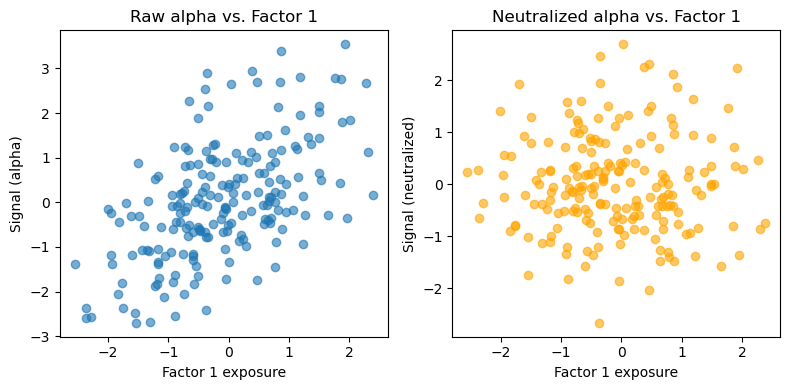

In [56]:
factor = df["factor_1"].to_numpy()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.scatter(factor, y, alpha=0.6)
plt.title("Raw alpha vs. Factor 1")
plt.xlabel("Factor 1 exposure")
plt.ylabel("Signal (alpha)")

plt.subplot(1,2,2)
plt.scatter(factor, alpha_neutralized, alpha=0.6, color='orange')
plt.title("Neutralized alpha vs. Factor 1")
plt.xlabel("Factor 1 exposure")
plt.ylabel("Signal (neutralized)")
plt.tight_layout()
plt.show()
